desarrollar una comparacion para diferentes modelos de regresion: lineal, polinomial, logaritmica, con la DB boston housing, californa housing. Mostrar metricas y lineas de estimacion. Incluir cross-validation

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    PolynomialFeatures,
    FunctionTransformer
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5

sns.set_theme(style="whitegrid")

In [ ]:
def cargar_datasets():
    # California Housing
    california = fetch_california_housing(as_frame=True)

    X_california = california.data.astype(float)
    y_california = california.target.astype(float)

    # Boston Housing desde OpenML
    boston = fetch_openml(
        name="boston",
        version=1,
        as_frame=True,
        parser="auto"
    )

    X_boston = boston.data.apply(
        pd.to_numeric,
        errors="coerce"
    ).astype(float)

    y_boston = pd.to_numeric(
        boston.target,
        errors="coerce"
    ).astype(float)

    return {
        "Boston Housing": (
            X_boston,
            y_boston,
            "LSTAT",
            "Precio mediano (miles de USD)"
        ),
        "California Housing": (
            X_california,
            y_california,
            "MedInc",
            "Valor mediano (cientos de miles de USD)"
        )
    }


datasets = cargar_datasets()

for nombre, (X, y, variable, unidad) in datasets.items():
    print(f"\n{nombre}")
    print(f"Filas: {X.shape[0]}")
    print(f"Variables predictoras: {X.shape[1]}")
    print(f"Variable para la curva: {variable}")
    print(f"Unidad del objetivo: {unidad}")

    display(X.head())


Boston Housing
Filas: 506
Variables predictoras: 13
Variable para la curva: LSTAT
Unidad del objetivo: Precio mediano (miles de USD)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33



California Housing
Filas: 20640
Variables predictoras: 8
Variable para la curva: MedInc
Unidad del objetivo: Valor mediano (cientos de miles de USD)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
def signed_log1p(X):
    """
    Transformación logarítmica que admite números
    positivos, negativos y cero.
    """
    X = np.asarray(X, dtype=float)

    return np.sign(X) * np.log1p(np.abs(X))


modelos = {
    "Lineal": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]),

    "Polinomial grado 2": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "polynomial",
            PolynomialFeatures(
                degree=2,
                include_bias=False
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "regressor",
            LinearRegression()
        )
    ]),

    "Logarítmica": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "logarithm",
            FunctionTransformer(
                signed_log1p,
                validate=False
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "regressor",
            LinearRegression()
        )
    ])
}


cv = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

metricas_cv = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [ ]:
resultados = []
predicciones = {}
modelos_ajustados = {}
particiones = {}

for dataset_nombre, informacion in datasets.items():

    X, y, variable_curva, unidad = informacion

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )

    particiones[dataset_nombre] = (
        X_train,
        X_test,
        y_train,
        y_test
    )

    for modelo_nombre, modelo_base in modelos.items():

        # Crear un modelo independiente para cada dataset
        modelo = clone(modelo_base)

        # Validación cruzada
        scores = cross_validate(
            modelo,
            X_train,
            y_train,
            cv=cv,
            scoring=metricas_cv,
            n_jobs=-1
        )

        # Entrenar el modelo con el dataset actual
        modelo.fit(X_train, y_train)

        # Realizar predicciones
        y_pred = modelo.predict(X_test)

        # Guardar predicciones
        predicciones[
            (dataset_nombre, modelo_nombre)
        ] = y_pred

        # Guardar un modelo diferente para cada dataset
        modelos_ajustados[
            (dataset_nombre, modelo_nombre)
        ] = modelo

        resultados.append({
            "Dataset": dataset_nombre,
            "Modelo": modelo_nombre,

            "MAE prueba":
                mean_absolute_error(y_test, y_pred),

            "RMSE prueba":
                mean_squared_error(y_test, y_pred) ** 0.5,

            "R² prueba":
                r2_score(y_test, y_pred),

            "MAE CV media":
                -scores["test_MAE"].mean(),

            "MAE CV desviación":
                scores["test_MAE"].std(),

            "RMSE CV media":
                -scores["test_RMSE"].mean(),

            "RMSE CV desviación":
                scores["test_RMSE"].std(),

            "R² CV media":
                scores["test_R2"].mean(),

            "R² CV desviación":
                scores["test_R2"].std()
        })


tabla_resultados = pd.DataFrame(resultados)

tabla_resultados = tabla_resultados.sort_values(
    ["Dataset", "RMSE CV media"]
).reset_index(drop=True)

display(tabla_resultados.round(4))

,Dataset,Modelo,MAE prueba,RMSE prueba,R² prueba,MAE CV media,MAE CV desviación,RMSE CV media,RMSE CV desviación,R² CV media,R² CV desviación
0,Boston Housing,Logarítmica,2.9300,4.2973,0.7482,3.2777,0.3599,4.3974,0.5760,0.7717,0.0465
1,Boston Housing,Polinomial grado 2,2.5748,3.7759,0.8056,2.9700,0.1843,4.7821,0.8281,0.7031,0.1613
2,Boston Housing,Lineal,3.1891,4.9286,0.6688,3.4284,0.4217,4.8663,0.7986,0.7185,0.0784
3,California Housing,Logarítmica,0.5321,0.7150,0.6099,0.5282,0.0091,0.7059,0.0157,0.6270,0.0133
4,California Housing,Lineal,0.5332,0.7456,0.5758,0.5291,0.0094,0.7205,0.0139,0.6115,0.0124
5,California Housing,Polinomial grado 2,0.4670,0.6814,0.6457,0.4848,0.0374,1.3903,1.3797,-1.8847,5.0284


In [ ]:
print("""
INTERPRETACIÓN DE LAS MÉTRICAS

MAE:
Error absoluto promedio.
Entre más pequeño sea, mejor es el modelo.

RMSE:
Penaliza con mayor fuerza los errores grandes.
Entre más pequeño sea, mejor.

R²:
Indica qué proporción de la variabilidad logra
explicar el modelo.
Entre más cercano a 1, mejor.

Media de cross-validation:
Rendimiento promedio en los cinco pliegues.

Desviación de cross-validation:
Indica cuánto cambian los resultados entre pliegues.
Una desviación pequeña representa mayor estabilidad.
""")


INTERPRETACIÓN DE LAS MÉTRICAS

MAE:
Error absoluto promedio.
Entre más pequeño sea, mejor es el modelo.

RMSE:
Penaliza con mayor fuerza los errores grandes.
Entre más pequeño sea, mejor.

R²:
Indica qué proporción de la variabilidad logra
explicar el modelo.
Entre más cercano a 1, mejor.

Media de cross-validation:
Rendimiento promedio en los cinco pliegues.

Desviación de cross-validation:
Indica cuánto cambian los resultados entre pliegues.
Una desviación pequeña representa mayor estabilidad.



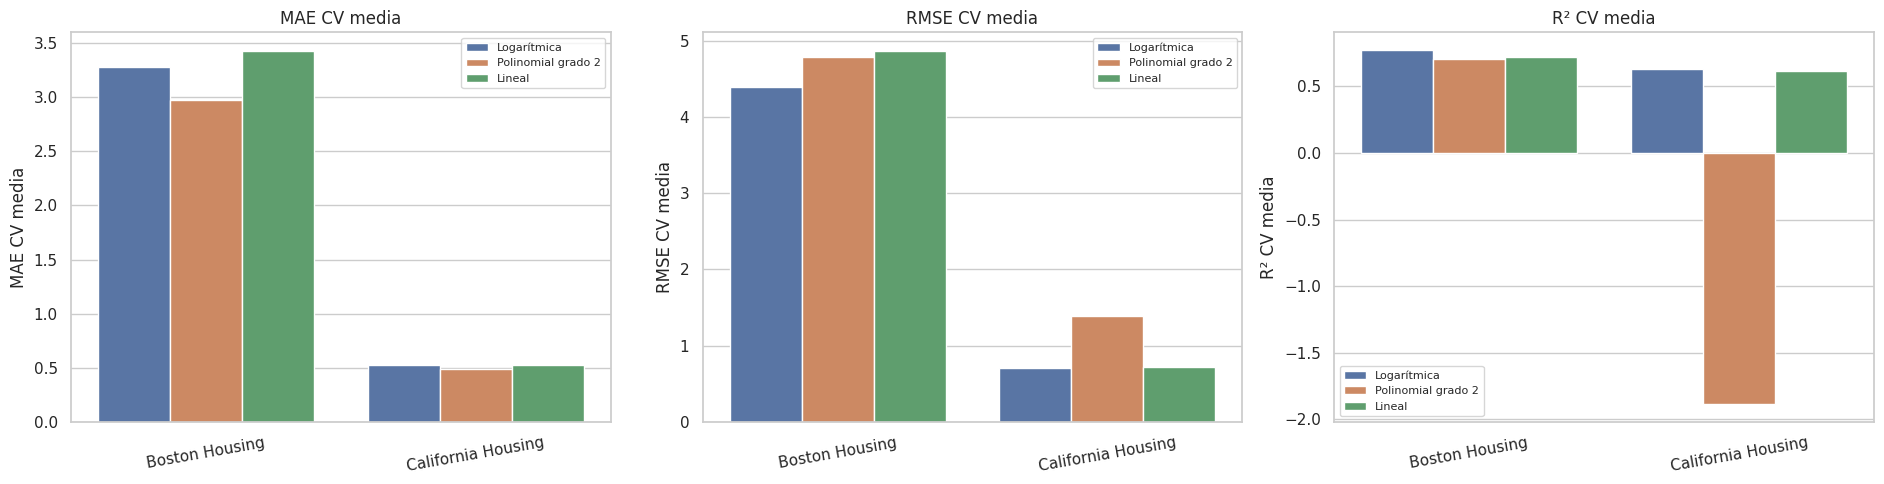

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 5)
)

metricas_grafica = [
    "MAE CV media",
    "RMSE CV media",
    "R² CV media"
]

for ax, metrica in zip(axes, metricas_grafica):

    sns.barplot(
        data=tabla_resultados,
        x="Dataset",
        y=metrica,
        hue="Modelo",
        ax=ax
    )

    ax.set_title(metrica)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

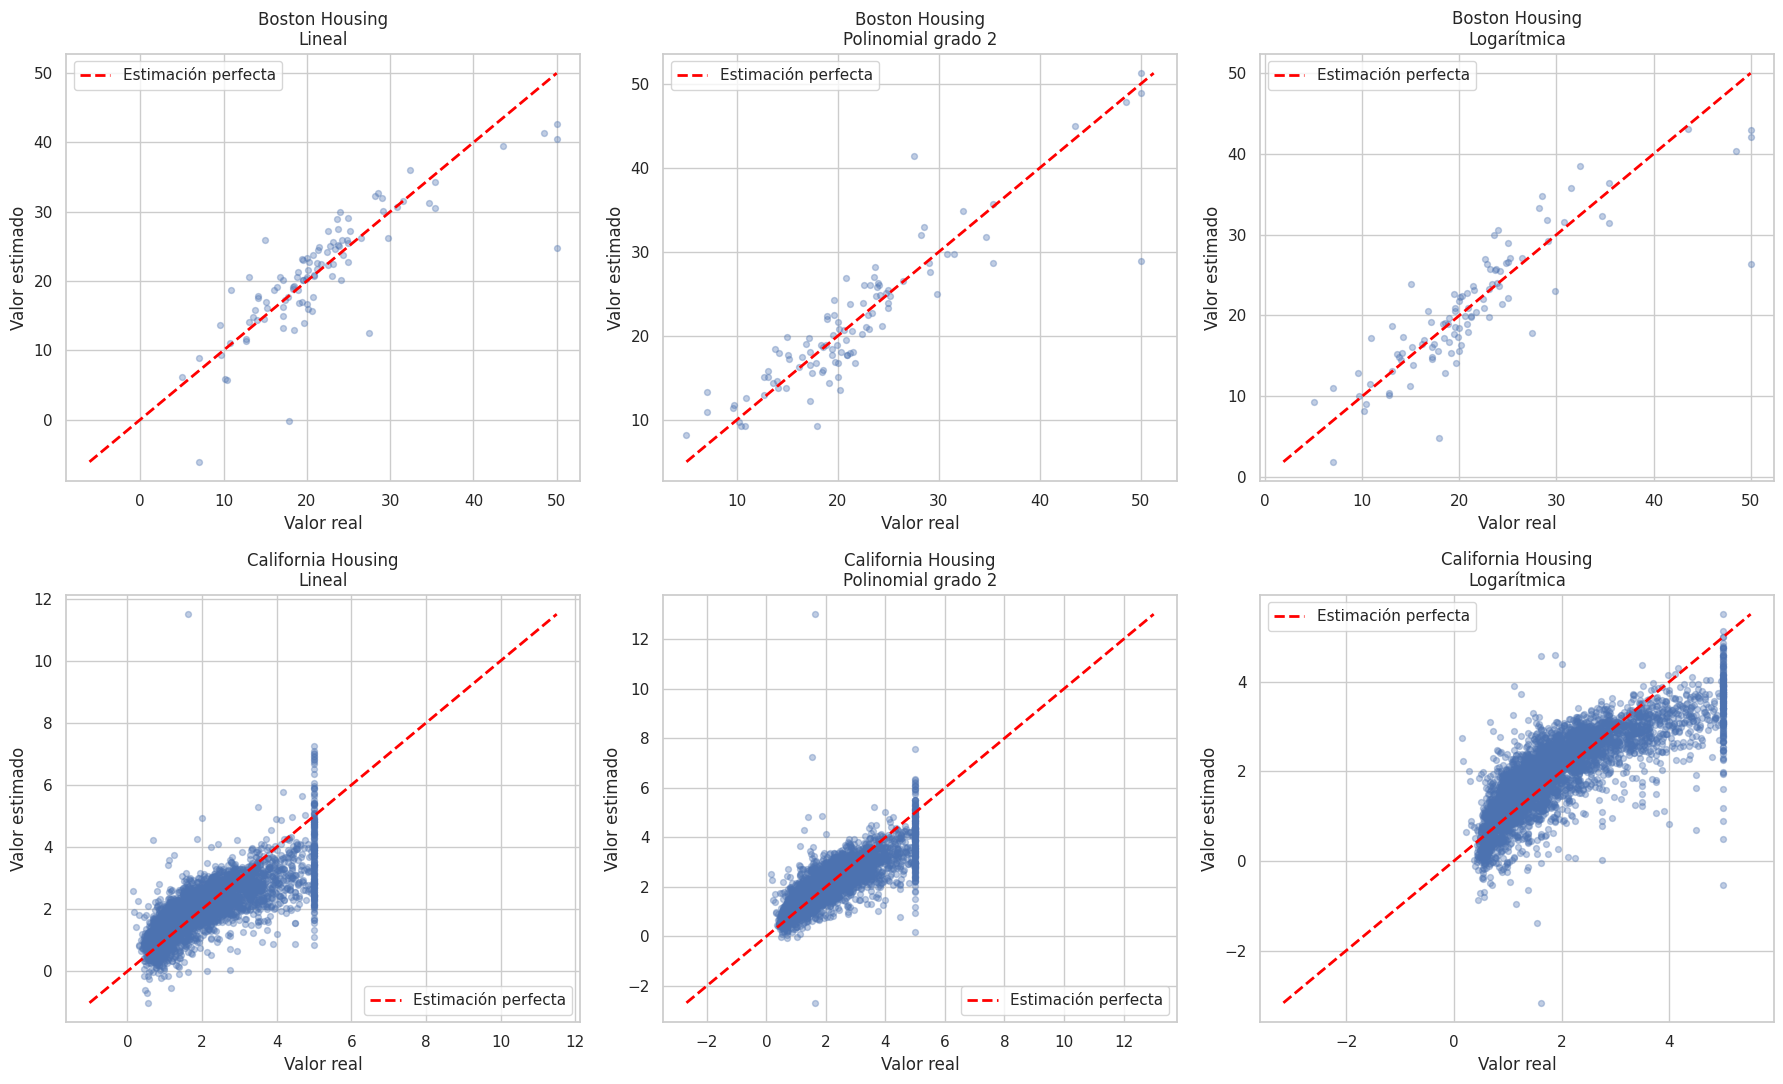

In [ ]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11)
)

for fila, dataset_nombre in enumerate(datasets):

    X_train, X_test, y_train, y_test = (
        particiones[dataset_nombre]
    )

    for columna, modelo_nombre in enumerate(modelos):

        ax = axes[fila, columna]

        y_pred = predicciones[
            (dataset_nombre, modelo_nombre)
        ]

        ax.scatter(
            y_test,
            y_pred,
            alpha=0.35,
            s=18
        )

        minimo = min(
            y_test.min(),
            y_pred.min()
        )

        maximo = max(
            y_test.max(),
            y_pred.max()
        )

        ax.plot(
            [minimo, maximo],
            [minimo, maximo],
            color="red",
            linestyle="--",
            linewidth=2,
            label="Estimación perfecta"
        )

        ax.set_title(
            f"{dataset_nombre}\n{modelo_nombre}"
        )

        ax.set_xlabel("Valor real")
        ax.set_ylabel("Valor estimado")
        ax.legend()

plt.tight_layout()
plt.show()

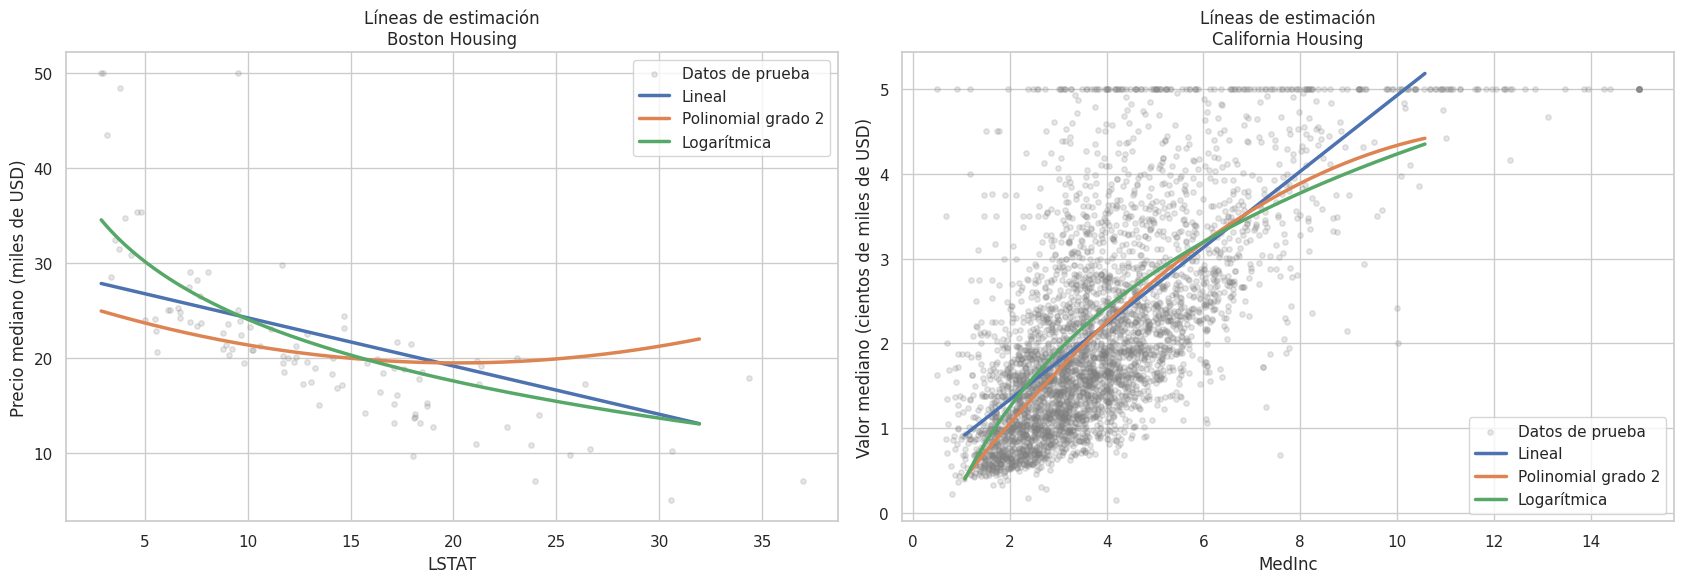

In [ ]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 6)
)

for ax, (dataset_nombre, informacion) in zip(
    axes,
    datasets.items()
):

    X, y, variable, unidad = informacion

    X_train, X_test, y_train, y_test = (
        particiones[dataset_nombre]
    )

    limite_inferior = X_train[variable].quantile(0.01)
    limite_superior = X_train[variable].quantile(0.99)

    rejilla = np.linspace(
        limite_inferior,
        limite_superior,
        250
    )

    # Crear una fila con la mediana de cada variable
    medianas = X_train.median()

    base = pd.DataFrame(
        [medianas] * len(rejilla)
    )

    # Garantizar el mismo orden de columnas usado al entrenar
    base = base[X_train.columns]

    # Variar solamente la característica seleccionada
    base[variable] = rejilla

    ax.scatter(
        X_test[variable],
        y_test,
        alpha=0.20,
        s=15,
        color="gray",
        label="Datos de prueba"
    )

    for modelo_nombre in modelos.keys():

        modelo = modelos_ajustados[
            (dataset_nombre, modelo_nombre)
        ]

        estimacion = modelo.predict(base)

        ax.plot(
            rejilla,
            estimacion,
            linewidth=2.5,
            label=modelo_nombre
        )

    ax.set_title(
        f"Líneas de estimación\n{dataset_nombre}"
    )

    ax.set_xlabel(variable)
    ax.set_ylabel(unidad)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
indices_mejores = tabla_resultados.groupby(
    "Dataset"
)["RMSE CV media"].idxmin()

mejores_modelos = tabla_resultados.loc[
    indices_mejores,
    [
        "Dataset",
        "Modelo",
        "RMSE CV media",
        "R² CV media",
        "RMSE prueba",
        "R² prueba"
    ]
]

display(mejores_modelos.round(4))

print("\nCONCLUSIONES AUTOMÁTICAS\n")

for _, fila in mejores_modelos.iterrows():

    print(
        f"En {fila['Dataset']}, el mejor modelo según "
        f"el RMSE de validación cruzada es "
        f"{fila['Modelo']}."
    )

    print(
        f"RMSE promedio de CV: "
        f"{fila['RMSE CV media']:.4f}"
    )

    print(
        f"R² promedio de CV: "
        f"{fila['R² CV media']:.4f}"
    )

    print(
        f"RMSE en prueba: "
        f"{fila['RMSE prueba']:.4f}"
    )

    print(
        f"R² en prueba: "
        f"{fila['R² prueba']:.4f}\n"
    )

,Dataset,Modelo,RMSE CV media,R² CV media,RMSE prueba,R² prueba
0,Boston Housing,Logarítmica,4.3974,0.7717,4.2973,0.7482
3,California Housing,Logarítmica,0.7059,0.6270,0.7150,0.6099



CONCLUSIONES AUTOMÁTICAS

En Boston Housing, el mejor modelo según el RMSE de validación cruzada es Logarítmica.
RMSE promedio de CV: 4.3974
R² promedio de CV: 0.7717
RMSE en prueba: 4.2973
R² en prueba: 0.7482

En California Housing, el mejor modelo según el RMSE de validación cruzada es Logarítmica.
RMSE promedio de CV: 0.7059
R² promedio de CV: 0.6270
RMSE en prueba: 0.7150
R² en prueba: 0.6099

